## Preprocessing opsummeret 
1: Vi har fulgt preprocessing tutorial fra mne. 

2: Benytter et Bandpass filter på signalet

3: Konvertere det rå sigal til optical density

4: Hvert epoch starter 2s før hvert trigger signal og slutter 15s efter


### Plotting funktioner kode (Ignore)

In [46]:
import numpy as np
from sklearn.decomposition import PCA
import mne
from sklearn.decomposition import FastICA
from mne import EpochsArray, pick_types
from sklearn.preprocessing import StandardScaler
from finger_tapping.preprocessing import simple_pipeline

def plot_mean(new_epochs):
    evoked_dict = {
        "Tapping/HbO": new_epochs["Tapping"].average(picks="hbo"),
        "Tapping/HbR": new_epochs["Tapping"].average(picks="hbr"),
        "Control/HbO": new_epochs["Control"].average(picks="hbo"),
        "Control/HbR": new_epochs["Control"].average(picks="hbr"),
    }

    # Rename channels until the encoding of frequency in ch_name is fixed
    for condition in evoked_dict:
        evoked_dict[condition].rename_channels(lambda x: x[:-4])

    color_dict = dict(HbO="#AA3377", HbR="b")
    styles_dict = dict(Control=dict(linestyle="dashed"))

    mne.viz.plot_compare_evokeds(
        evoked_dict, combine="mean", ci=0.95, colors=color_dict, styles=styles_dict
    )

def plot_scalp_mean(new_epochs):

    times = np.arange(-2, 13.2, 3.0)
    topomap_args = dict(extrapolate="local")
    new_epochs["Tapping"].average(picks="hbo").plot_joint(
        times=times, topomap_args=topomap_args
    )

def plot_scalp_map(new_epochs):  
    times = np.arange(1, 13, 1.0)
    topomap_args = dict(extrapolate="local")
    print()
        
    print("Tapping Left: Hbo")
    new_epochs["Tapping/Left"].average(picks="hbo").plot_topomap(times=times, **topomap_args)
    print("Tapping Left: Hbr")
    new_epochs["Tapping/Left"].average(picks="hbr").plot_topomap(times=times, **topomap_args)
    print()

    print("Tapping Right: Hbo")
    new_epochs["Tapping/Right"].average(picks="hbo").plot_topomap(times=times, **topomap_args)
    print("Tapping Right: Hbr")
    new_epochs["Tapping/Right"].average(picks="hbr").plot_topomap(times=times, **topomap_args)
    print()
    
    print("Control: Hbo")
    new_epochs["Control"].average(picks="hbo").plot_topomap(times=times, **topomap_args)
    print("Control: Hbr")
    new_epochs["Control"].average(picks="hbr").plot_topomap(times=times, **topomap_args)


### Definere bruger subject ### 
epochs = simple_pipeline(subject="01", tmin=-2, tmax=15)

Reading 0 ... 23238  =      0.000 ...  2974.464 secs...
Overwriting existing file.
Overwriting existing file.


# 1) Plot - Gennmemsnitlig aktivering

1) Epochs opdeles i tapping/control og hbo/hbr
2) Gennemsnittet af alle epochs tages og plottes som en tidsserie

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


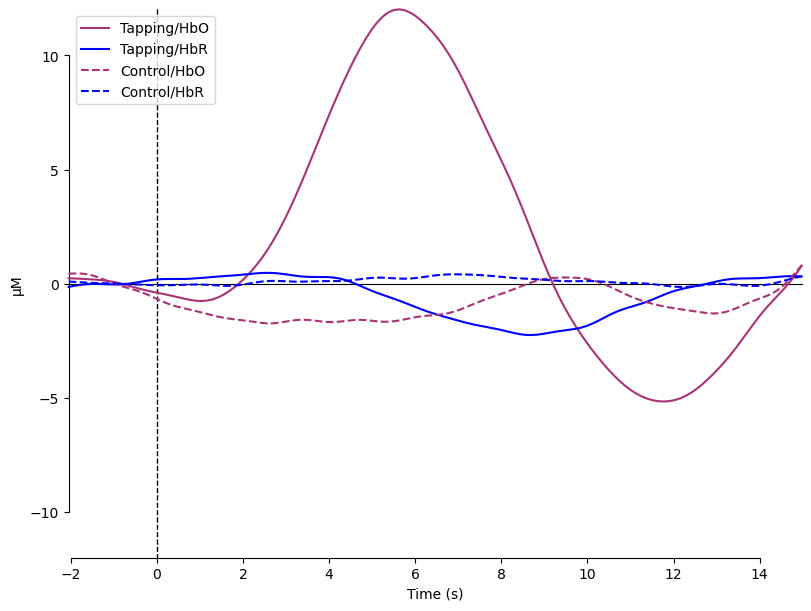

In [47]:
plot_mean(epochs)

# 1) Plot - Scalp map over gennemsnitlig hbo værdier over tid (Tapping)

No projector specified for this dataset. Please consider the method self.add_proj.


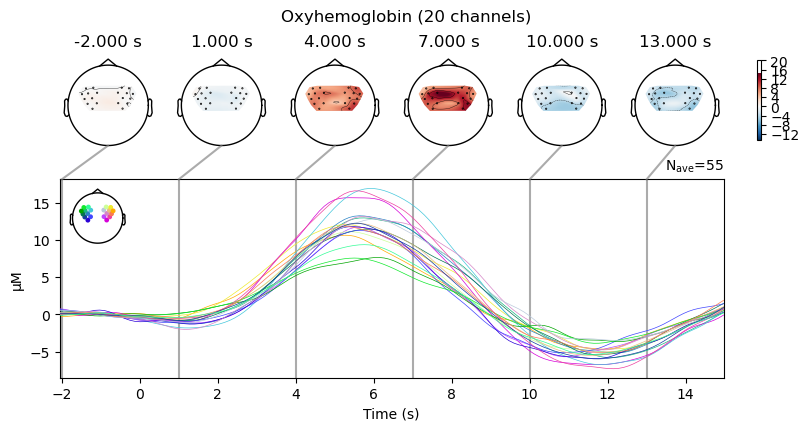

In [48]:
plot_scalp_mean(epochs)

# 3) Plot - Scalp map af aktivering af sensorer over tid opdelt i control/left/right og hbo/hbr


Tapping Left: Hbo


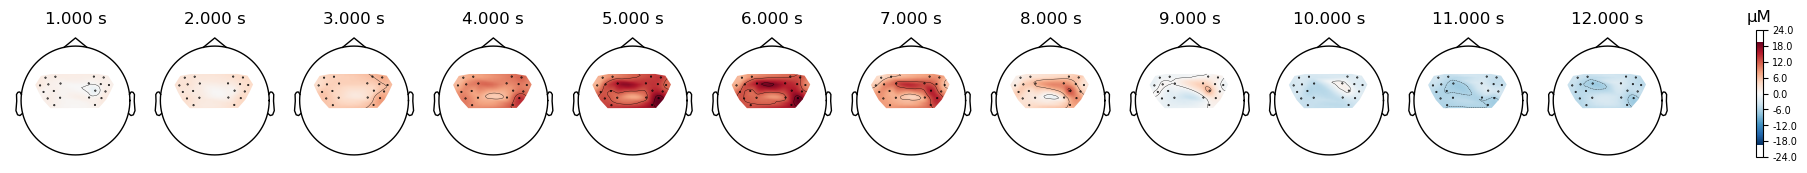

Tapping Left: Hbr


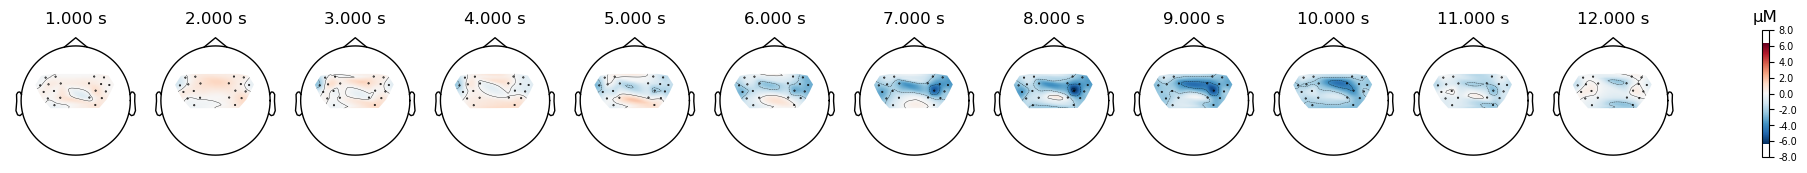


Tapping Right: Hbo


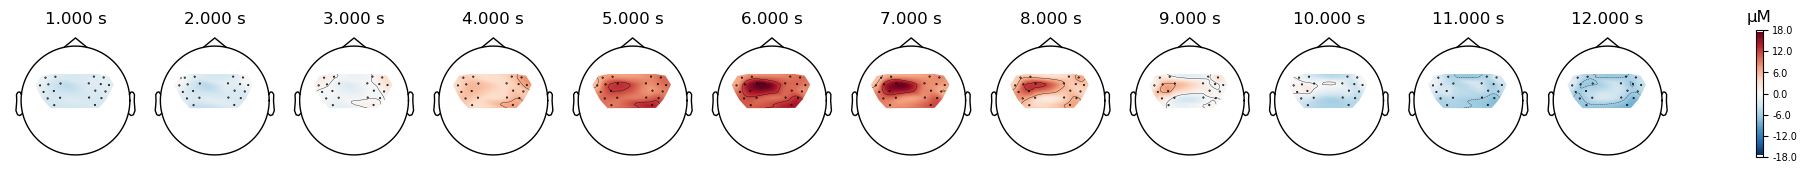

Tapping Right: Hbr


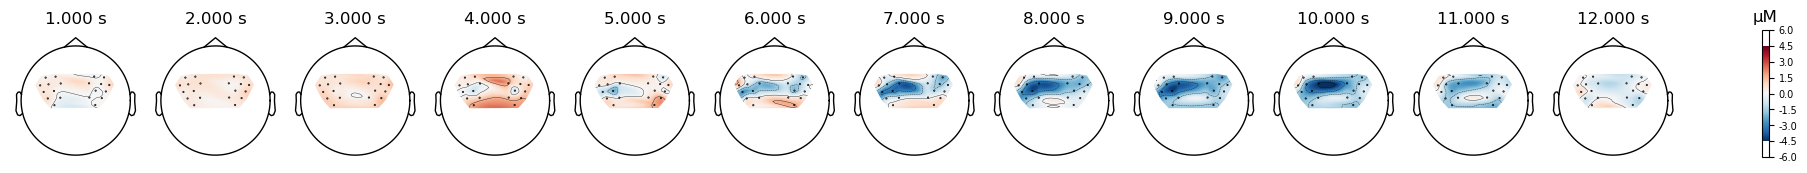


Control: Hbo


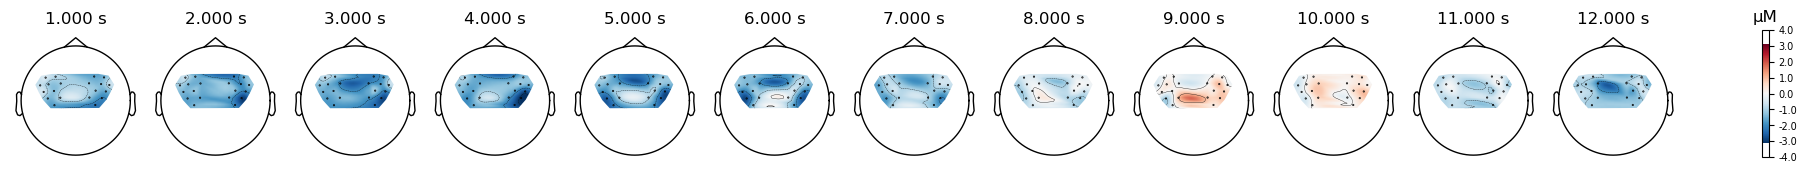

Control: Hbr


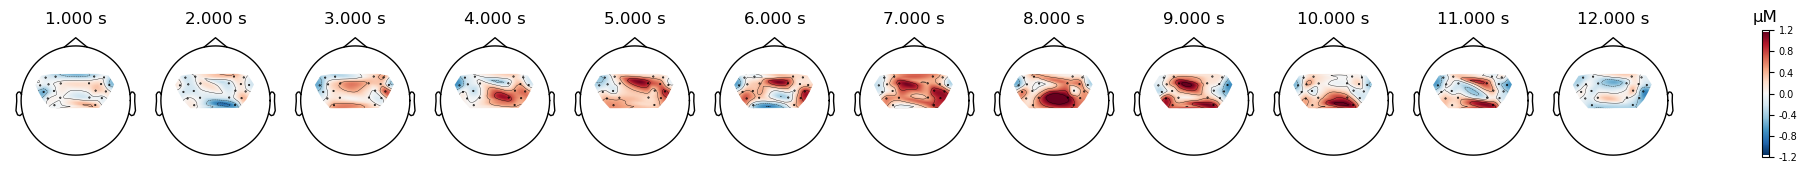

In [49]:
plot_scalp_map(epochs)

# Samme Scalp plots rekonstrureret med PCA 

In [ ]:
def reconstruct_epochs_with_pca(epochs: mne.Epochs, n_components: int = 1) -> mne.Epochs:
    data = epochs.get_data()  # (n_epochs, n_channels, n_times)
    n_epochs, n_channels, n_times = data.shape

    X = data.transpose(0, 2, 1).reshape(-1, n_channels)  
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) # (n_epochs*n_times, n_channels)
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X_scaled)                                   # (n_epochs*n_times, n_components)
    X_recon = pca.inverse_transform(scores)                         # (n_epochs*n_times, n_channels)

    data_recon = X_recon.reshape(n_epochs, n_times, n_channels).transpose(0, 2, 1)

    info = epochs.info.copy()
    events = epochs.events
    event_id = epochs.event_id
    tmin = epochs.tmin

    return EpochsArray(data_recon, info, events, tmin, event_id)

pca_epochs = reconstruct_epochs_with_pca(epochs, 2)

Not setting metadata
84 matching events found
No baseline correction applied
0 projection items activated


# Plot 1 rekonstrueret med 2 principal components

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


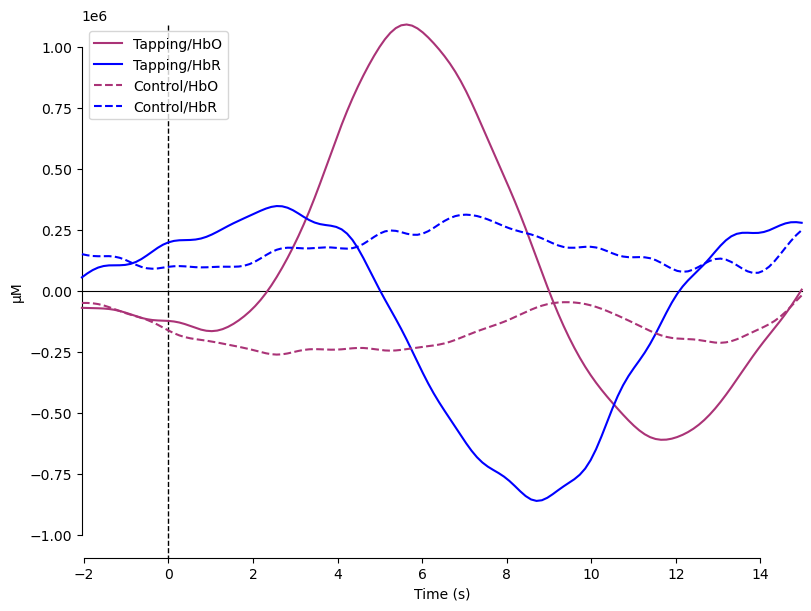

No projector specified for this dataset. Please consider the method self.add_proj.


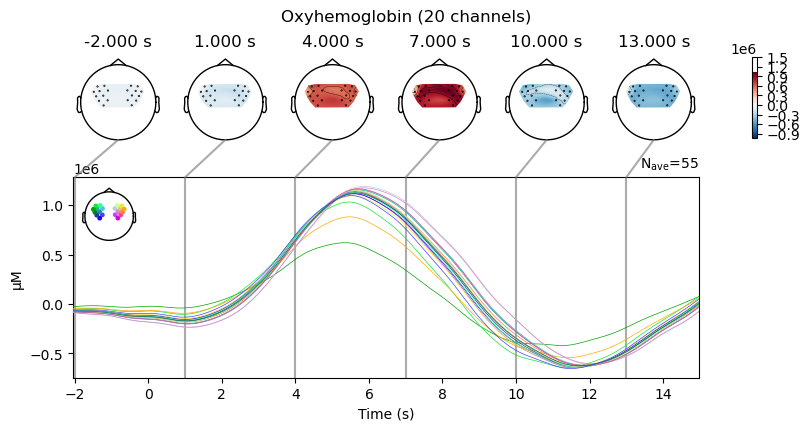


Tapping Left: Hbo


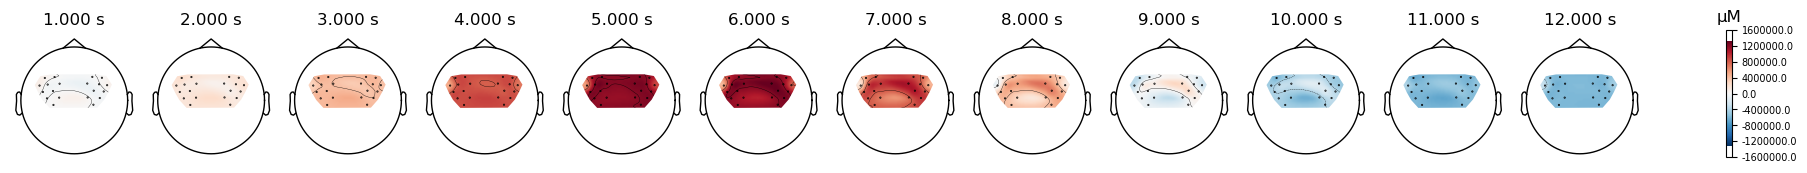

Tapping Left: Hbr


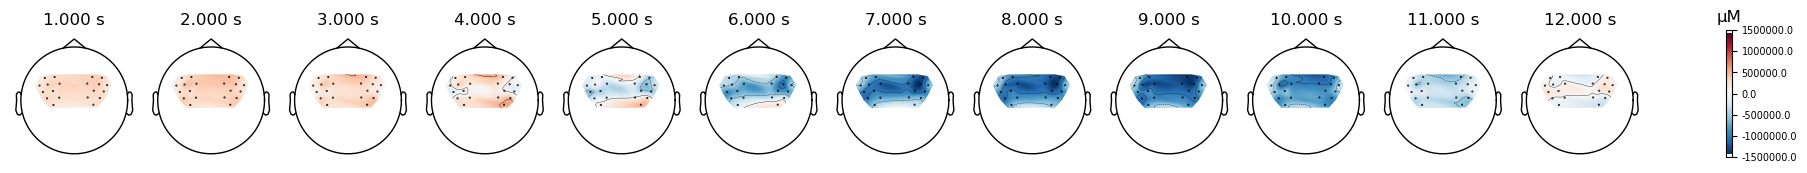


Tapping Right: Hbo


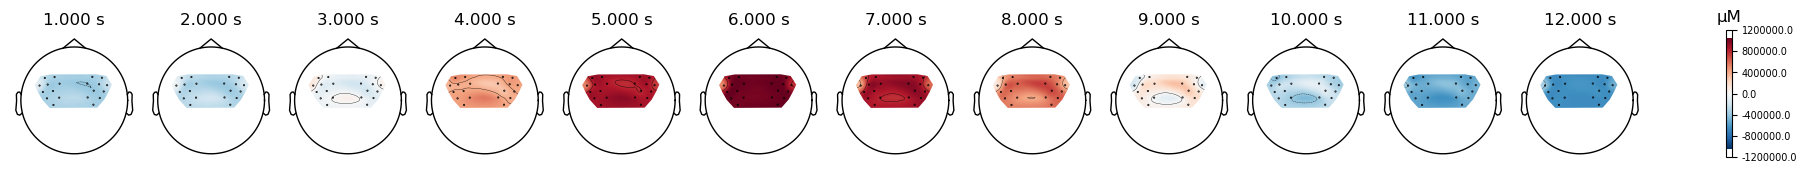

Tapping Right: Hbr


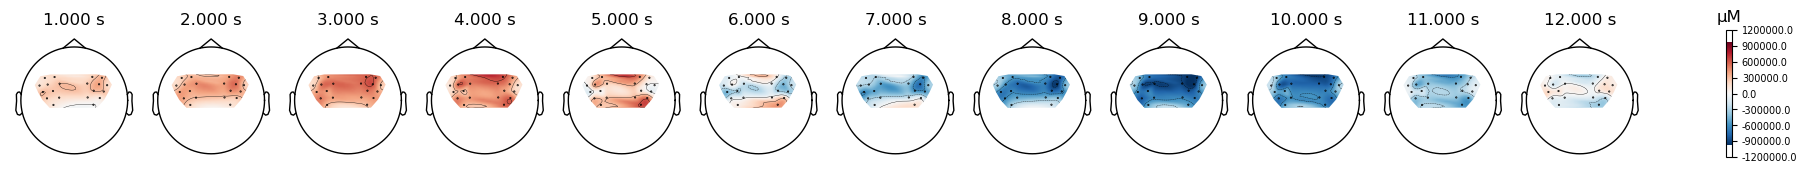


Control: Hbo


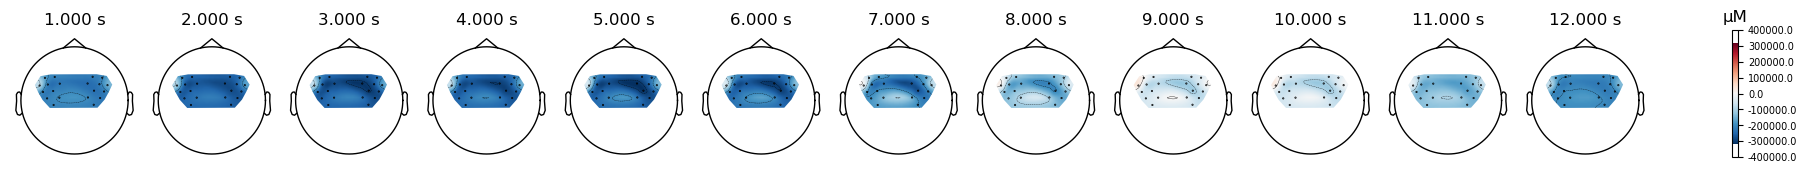

Control: Hbr


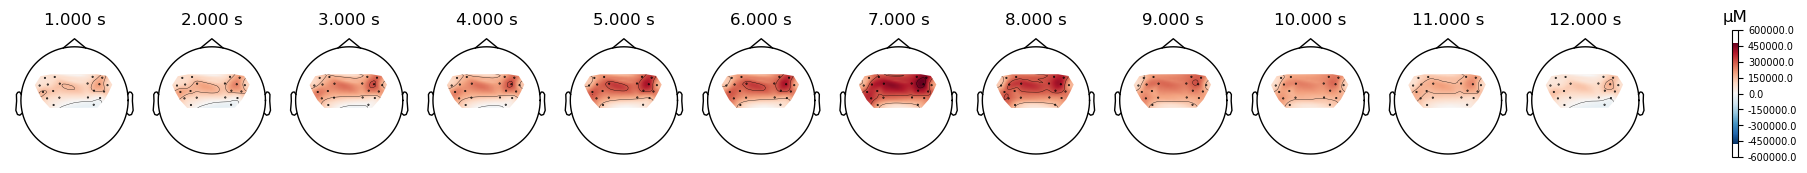

In [51]:
plot_mean(pca_epochs)
plot_scalp_mean(pca_epochs)
plot_scalp_map(pca_epochs)